# 50.007 Machine Learning — Homework 1



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder that holds the per-algorithm data subfolders.
DATA = 'HW1_data'

# Each question maps to the folder of the algorithm it implements.
FOLDERS = {
    1: 'perceptron',
    2: 'linear-and-polynomial-regression',
    3: 'ridge-regression',
    4: 'k-means',
}

def datapath(q, name):
    return os.path.join(DATA, FOLDERS[q], name)

# Q1 — Perceptron (linear classification)



In [2]:
# Load the data. Each row is: symmetry, intensity, label.
train = np.loadtxt(datapath(1, 'train_1_5.csv'), delimiter=',')
test = np.loadtxt(datapath(1, 'test_1_5.csv'), delimiter=',')

X_train, y_train = train[:, :2], train[:, 2]
X_test,  y_test  = test[:, :2],  test[:, 2]


def perceptron(X, y, epochs):
    # Perceptron with an offset. Visit points in order (no shuffling); only
    # update on a misclassification.
    theta = np.zeros(X.shape[1])
    theta_0 = 0.0
    for e in range(epochs):
        for i in range(len(X)):
            xi, yi = X[i], y[i]
            if yi * (np.dot(theta, xi) + theta_0) <= 0:
                theta = theta + yi * xi
                theta_0 = theta_0 + yi
    return theta, theta_0


def accuracy(X, y, theta, theta_0):
    # fraction of points classified correctly
    preds = np.sign(np.dot(X, theta) + theta_0)
    return np.mean(preds == y)


## Q1(a) — Perceptron with offset, 1 epoch

In [3]:
theta1, theta0_1 = perceptron(X_train, y_train, epochs=1)
acc1 = accuracy(X_test, y_test, theta1, theta0_1)

print('After 1 epoch:')
print('theta  =', theta1)
print('offset =', theta0_1)
print('test accuracy =', round(acc1, 4))


After 1 epoch:
theta  = [-2.4483233  -5.88190688]
offset = 0.0
test accuracy = 0.9671


## Q1(b) — Perceptron with offset, 5 epochs

In [4]:
theta5, theta0_5 = perceptron(X_train, y_train, epochs=5)
acc5 = accuracy(X_test, y_test, theta5, theta0_5)

print('After 5 epochs:')
print('theta  =', theta5)
print('offset =', theta0_5)
print('test accuracy =', round(acc5, 4))


After 5 epochs:
theta  = [-2.05895878 -8.83521606]
offset = 1.0
test accuracy = 0.9671


## Q1(c) — How to run

Refer to the report. 

# Q2 — Linear and polynomial regression



## Q2(a) — Closed-form linear regression

In [27]:
# Load x, y and prepend a column of 1s (bias term).
x = np.loadtxt(datapath(2, 'hw1x.dat'))
y = np.loadtxt(datapath(2, 'hw1y.dat'))
X = np.column_stack([np.ones(len(x)), x])
print('X shape:', X.shape, ' y shape:', y.shape)


def linear_regression(X, y):
    # Closed-form normal equations: theta = (X^T X)^(-1) X^T y
    return np.linalg.inv(X.T @ X) @ X.T @ y


def empirical_risk(X, y, theta):
    # empirical risk for the squared loss = (1/2) * mean squared error
    return np.mean((X @ theta - y) ** 2) / 2


theta_cf = linear_regression(X, y)
print('theta (bias, slope):', np.round(theta_cf, 4))
print('training empirical risk:', round(empirical_risk(X, y, theta_cf), 4))

X shape: (200, 2)  y shape: (200,)
theta (bias, slope): [3.2447 1.7816]
training empirical risk: 0.5813


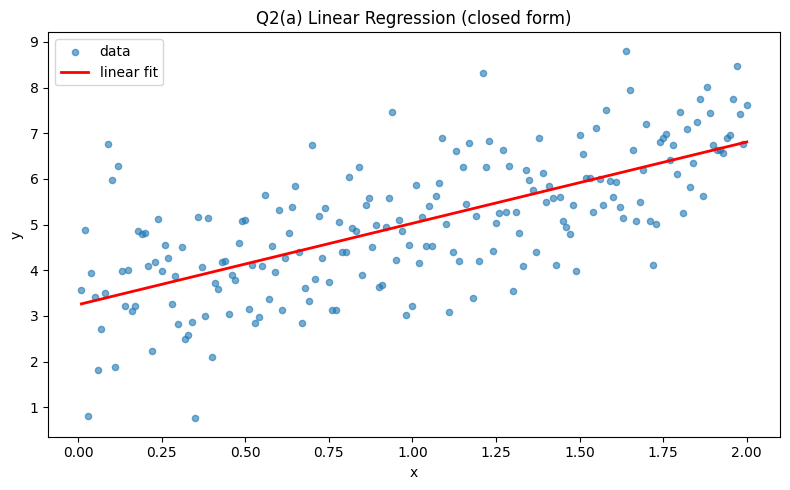

In [28]:
# Plot the data and the fitted line.
x_line = np.linspace(x.min(), x.max(), 200)
y_line = theta_cf[0] + theta_cf[1] * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='data')
plt.plot(x_line, y_line, 'r', linewidth=2, label='linear fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q2(a) Linear Regression (closed form)')
plt.legend(); plt.tight_layout()
plt.show()


## Q2(b) — Gradient descent and stochastic gradient descent

Both use learning rate $\eta=0.01$ for 5 epochs. We report the final $\theta$ and
the training error (empirical risk).


In [29]:
def gradient_descent(X, y, eta=0.01, epochs=5):
    # Batch GD: one update per epoch using the full-data gradient.
    # Track the best theta (lowest empirical risk) seen so far.
    n = X.shape[0]
    theta = np.zeros(X.shape[1])
    best_theta = theta.copy()
    best_risk = float('inf')
    errors = []
    for e in range(epochs):
        theta = theta - eta * (X.T @ (X @ theta - y) / n)
        current_risk = empirical_risk(X, y, theta)
        if current_risk < best_risk:
            best_risk = current_risk
            best_theta = theta.copy()
        errors.append(current_risk)
    return best_theta, best_risk, errors


def stochastic_gradient_descent(X, y, eta=0.01, epochs=5):
    # SGD: one update per step on a randomly drawn sample (epoch * n steps).
    # Track the best theta (lowest empirical risk) seen so far.
    np.random.seed(0)
    n = X.shape[0]
    theta = np.zeros(X.shape[1])
    best_theta = theta.copy()
    best_risk = float('inf')
    errors = []
    for e in range(epochs):
        for _ in range(n):
            j = np.random.randint(n)
            xj = X[j]
            yj = y[j]
            theta = theta + eta * np.dot((yj - np.dot(theta, xj)), xj)
            current_risk = empirical_risk(X, y, theta)
            if current_risk < best_risk:
                best_risk = current_risk
                best_theta = theta.copy()
        errors.append(empirical_risk(X, y, theta))
    return best_theta, best_risk, errors


theta_gd, risk_gd, errors_gd = gradient_descent(X, y)
theta_sgd, risk_sgd, errors_sgd = stochastic_gradient_descent(X, y)
print('Batch GD final theta:', np.round(theta_gd, 4),
      ' min empirical risk:', round(risk_gd, 4))
print('SGD      final theta:', np.round(theta_sgd, 4),
      ' min empirical risk:', round(risk_sgd, 4))

Batch GD final theta: [0.2413 0.2703]  min empirical risk: 11.1872
SGD      final theta: [2.9506 2.0699]  min empirical risk: 0.5951


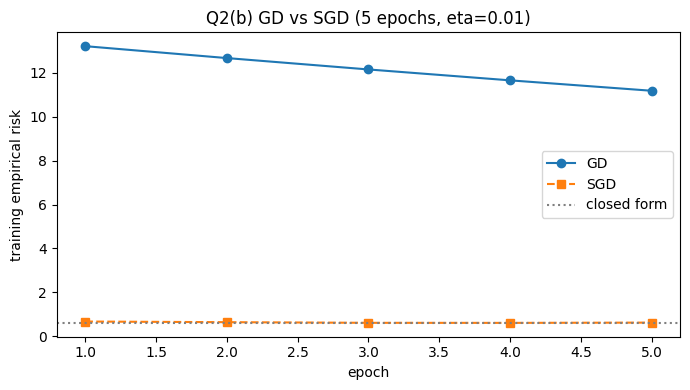

In [30]:
# Compare how fast each method drives the error down.
ep = range(1, 6)
plt.figure(figsize=(7, 4))
plt.plot(ep, errors_gd, 'o-', label='GD')
plt.plot(ep, errors_sgd, 's--', label='SGD')
plt.axhline(empirical_risk(X, y, theta_cf), color='gray', linestyle=':', label='closed form')
plt.xlabel('epoch'); plt.ylabel('training empirical risk')
plt.title('Q2(b) GD vs SGD (5 epochs, eta=0.01)')
plt.legend(); plt.tight_layout()
plt.show()

## Q2(c) — Polynomial regression

`PolyRegress(x, y, d)` builds the design matrix $[1, x, x^2, \dots, x^d]$ and
solves it with the same closed form. We give the quadratic (d=2) fit, then sweep
d = 3 … 15 and report the training error.


degree-2 theta: [3.5808 0.7834 0.4966]
degree-2 empirical risk: 0.5703


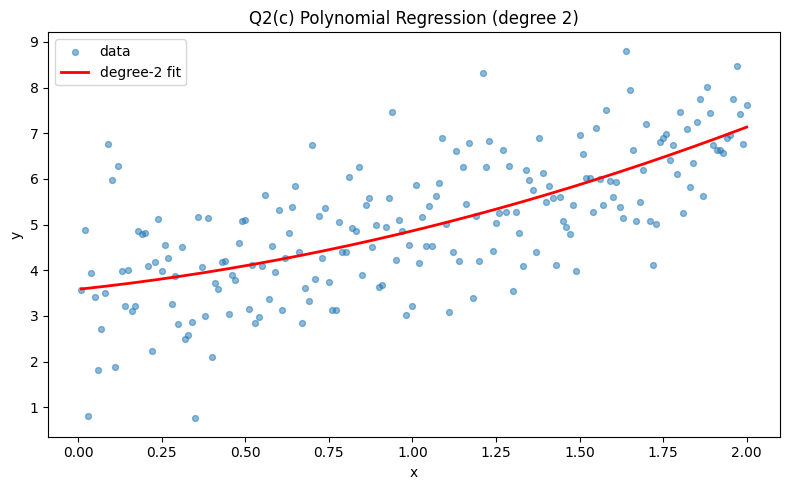

In [31]:
def PolyRegress(x, y, d):
    # Build [1, x, x^2, ..., x^d] and reuse the closed-form solver.
    X_poly = np.column_stack([x ** k for k in range(d + 1)])
    theta = linear_regression(X_poly, y)
    return theta, empirical_risk(X_poly, y, theta)


def poly_predict(theta, x):
    return sum(theta[k] * x ** k for k in range(len(theta)))


theta2, risk2 = PolyRegress(x, y, 2)
print('degree-2 theta:', np.round(theta2, 4))
print('degree-2 empirical risk:', round(risk2, 4))

x_line = np.linspace(x.min(), x.max(), 300)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=18, alpha=0.5, label='data')
plt.plot(x_line, poly_predict(theta2, x_line), 'r', linewidth=2, label='degree-2 fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q2(c) Polynomial Regression (degree 2)')
plt.legend(); plt.tight_layout()
plt.show()

In [34]:
# Fit degrees 1..15 and record the training empirical risk.
degrees = list(range(1, 16))
risk_list, theta_list = [], []
for d in degrees:
    th, er = PolyRegress(x, y, d)
    theta_list.append(th); risk_list.append(er)
    print('degree', d, '-> empirical risk', round(er, 4))

degree 1 -> empirical risk 0.5813
degree 2 -> empirical risk 0.5703
degree 3 -> empirical risk 0.5701
degree 4 -> empirical risk 0.5646
degree 5 -> empirical risk 0.5639
degree 6 -> empirical risk 0.5613
degree 7 -> empirical risk 0.5562
degree 8 -> empirical risk 0.5538
degree 9 -> empirical risk 0.5529
degree 10 -> empirical risk 0.5526
degree 11 -> empirical risk 0.7201
degree 12 -> empirical risk 3.2199
degree 13 -> empirical risk 4.6606
degree 14 -> empirical risk 2.8838
degree 15 -> empirical risk 50.2611


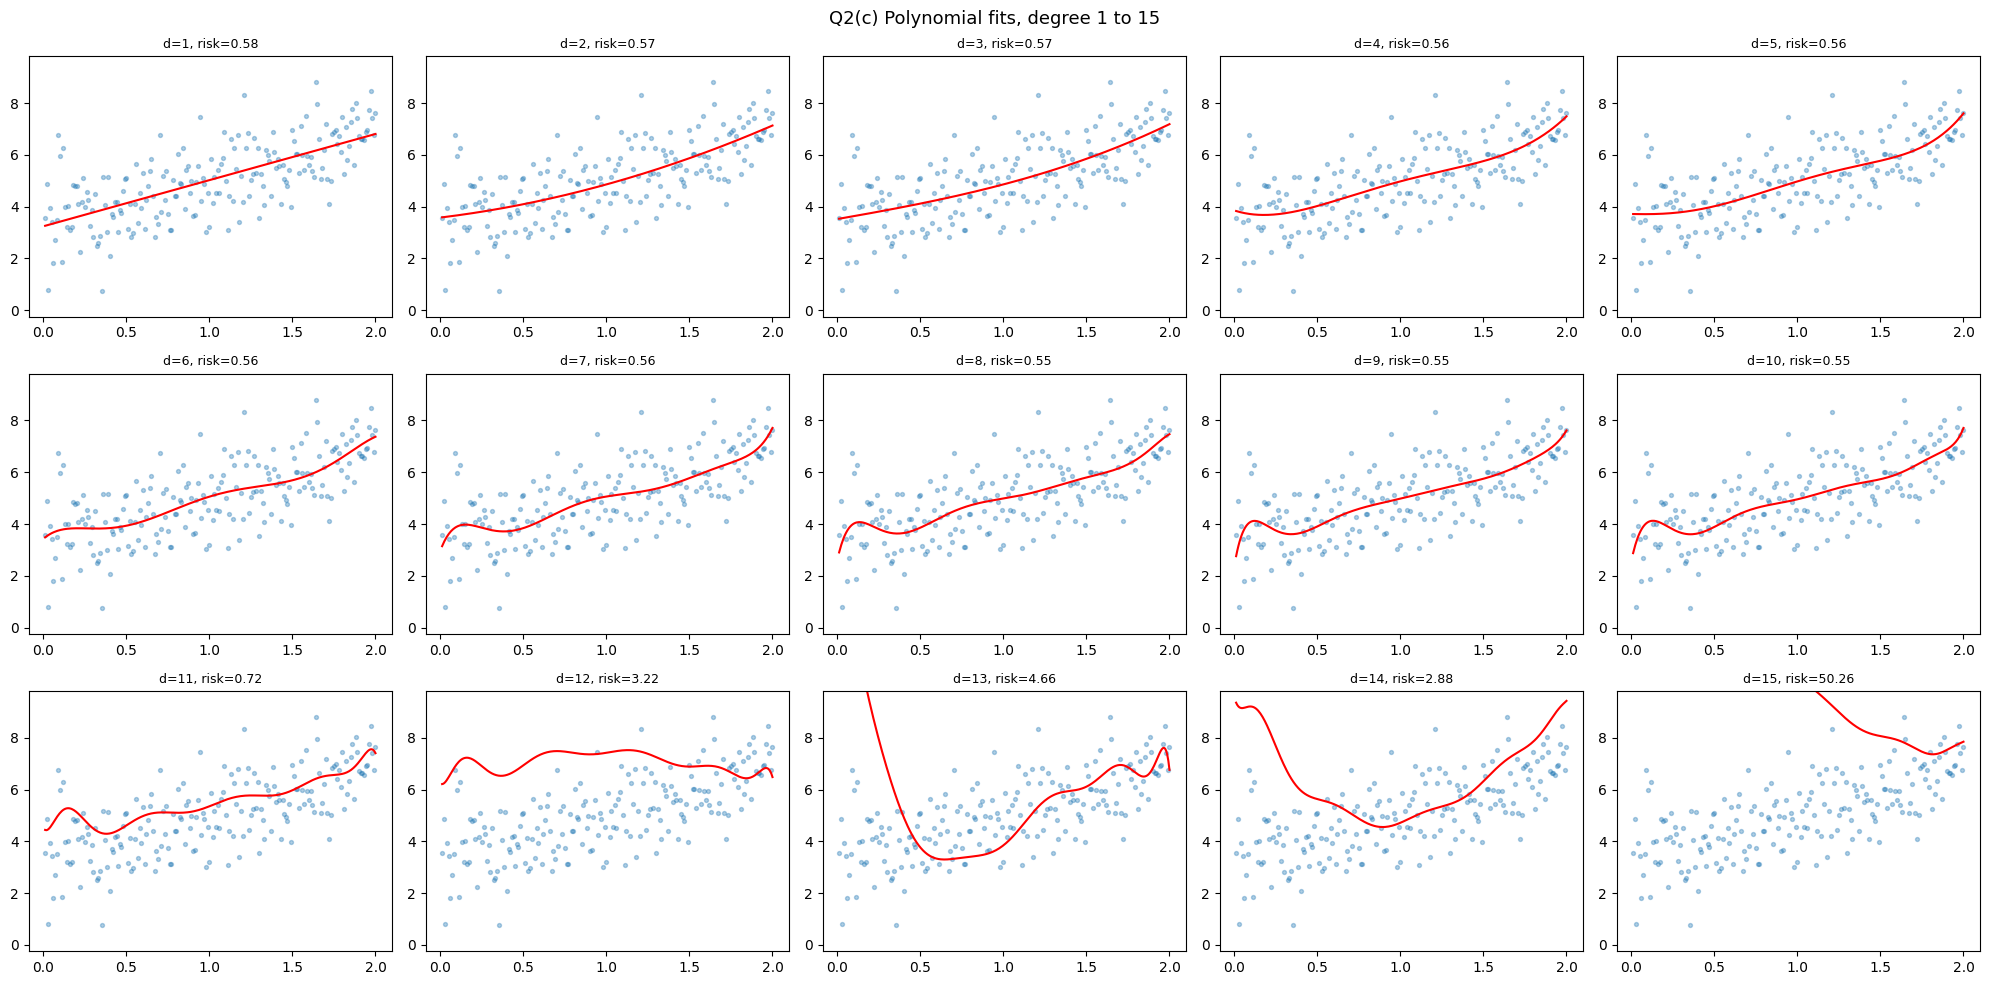

In [35]:
# All 15 fits in a grid.
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
for i, ax in enumerate(axes.flatten()):
    ax.scatter(x, y, s=8, alpha=0.35)
    ax.plot(x_line, poly_predict(theta_list[i], x_line), 'r', linewidth=1.5)
    ax.set_ylim(y.min() - 1, y.max() + 1)
    ax.set_title(f'd={degrees[i]}, risk={round(risk_list[i], 2)}', fontsize=9)
plt.suptitle('Q2(c) Polynomial fits, degree 1 to 15', fontsize=13)
plt.tight_layout(); plt.show()

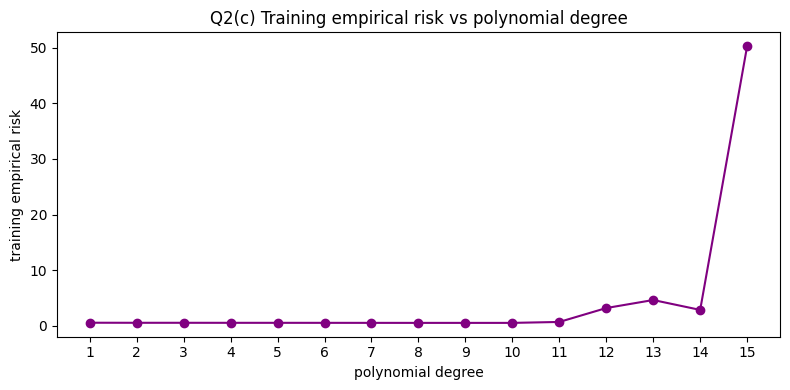

Error first gets worse at degree 11 : 0.5526 -> 0.7201


In [36]:
# Training error vs degree, and the first degree where error increases.
plt.figure(figsize=(8, 4))
plt.plot(degrees, risk_list, 'o-', color='purple')
plt.xlabel('polynomial degree'); plt.ylabel('training empirical risk')
plt.title('Q2(c) Training empirical risk vs polynomial degree')
plt.xticks(degrees); plt.tight_layout(); plt.show()

for i in range(1, len(risk_list)):
    if risk_list[i] > risk_list[i - 1]:
        print('Error first gets worse at degree', degrees[i],
              ':', round(risk_list[i - 1], 4), '->', round(risk_list[i], 4))
        break

**Why the error gets worse at high degree.**

Check report


# Q3 — Ridge regression


In [13]:
Xr = np.loadtxt(datapath(3, 'hw1_ridge_x.dat'), delimiter=',')
yr = np.loadtxt(datapath(3, 'hw1_ridge_y.dat'))

# first 10 -> validation, last 40 -> training
vX, vY = Xr[:10], yr[:10]
tX, tY = Xr[10:], yr[10:]
print('training:', tX.shape, ' validation:', vX.shape)


training: (40, 4)  validation: (10, 4)


## Q3(a) — ridge_regression(tX, tY, l)

In [14]:
def ridge_regression(X, y, l):
    # closed-form ridge: theta = (n*l*I + X^T X)^(-1) X^T y
    n, d = X.shape
    return np.linalg.inv(n * l * np.eye(d) + X.T @ X) @ X.T @ y


theta_ridge = ridge_regression(tX, tY, 0.15)
print('theta for lambda = 0.15:')
print(theta_ridge)


theta for lambda = 0.15:
[-0.57939825  1.15033028  0.04934122 -1.59867896]


## Q3(b) — Choose lambda with the validation set




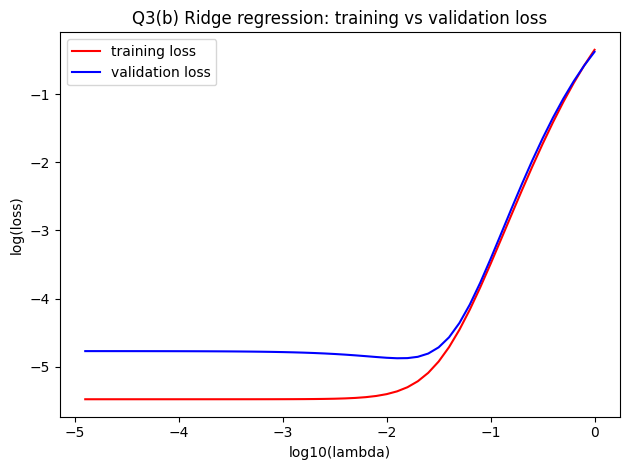

lambda minimising validation loss: 0.012589254117941668   (10 ^ -1.9 )


In [15]:
tn = tX.shape[0]
vn = vX.shape[0]
index = -np.arange(0, 5, 0.1)         # log10(lambda): 0 down to -4.9
tloss, vloss = [], []
for i in index:
    w = ridge_regression(tX, tY, 10 ** i)
    tloss.append(np.sum((tX @ w - tY) ** 2) / tn / 2)
    vloss.append(np.sum((vX @ w - vY) ** 2) / vn / 2)

plt.plot(index, np.log(tloss), 'r', label='training loss')
plt.plot(index, np.log(vloss), 'b', label='validation loss')
plt.xlabel('log10(lambda)'); plt.ylabel('log(loss)')
plt.title('Q3(b) Ridge regression: training vs validation loss')
plt.legend(); plt.tight_layout(); plt.show()

best = int(np.argmin(vloss))
print('lambda minimising validation loss:', 10 ** index[best],
      '  (10 ^', round(index[best], 1), ')')


# Q4 — K-Means on an image



In [16]:
ROWS, COLS = 516, 407
img = np.loadtxt(datapath(4, 'kmeans-image.txt'))
print('data shape:', img.shape)

centroids_init = np.array([
    [255, 255, 255], [255,   0,   0], [128,   0,   0], [  0, 255,   0],
    [  0, 128,   0], [  0,   0, 255], [  0,   0, 128], [  0,   0,   0],
], dtype=float)
K = 8


data shape: (210012, 3)


In [17]:
def assign_clusters(data, centroids):
    # nearest centroid for each pixel (squared Euclidean distance)
    dist2 = np.zeros((len(data), K))
    for k in range(K):
        dist2[:, k] = np.sum((data - centroids[k]) ** 2, axis=1)
    return np.argmin(dist2, axis=1)


def update_centroids(data, labels, centroids):
    # move each centroid to the mean of its assigned pixels
    new = centroids.copy()
    for k in range(K):
        pts = data[labels == k]
        if len(pts) > 0:
            new[k] = pts.mean(axis=0)
    return new


def total_error(data, labels, centroids):
    # total within-cluster squared distance
    return sum(np.sum((data[labels == k] - centroids[k]) ** 2) for k in range(K))


In [18]:
# Run K-Means until assignments stop changing.
centroids = centroids_init.copy()
labels = None
it = 0
print('iter | error')
while True:
    it += 1
    new_labels = assign_clusters(img, centroids)
    err = total_error(img, new_labels, centroids)
    print(it, '|', round(err, 2))
    if labels is not None and np.array_equal(new_labels, labels):
        print('Converged after', it, 'iterations.')
        break
    labels = new_labels
    centroids = update_centroids(img, labels, centroids)


iter | error
1 | 1288503836.0


2 | 210294736.58


3 | 174481268.85


4 | 165262491.16
5 | 143531825.45


6 | 130990410.13


...

30 | 118120296.95
31 | 118001542.67
32 | 117944999.27
33 | 117919337.55


34 | 117905042.94
35 | 117893379.33
36 | 117889008.23
37 | 117887541.06


38 | 117886951.19
39 | 117886642.54
40 | 117886384.86


41 | 117886230.63
42 | 117886120.59
43 | 117886095.23
44 | 117886085.04


45 | 117886072.67
46 | 117886065.4
47 | 117886062.13
48 | 117886061.64
Converged after 48 iterations.


In [19]:
# Final centroids and pixel counts.
print('  k        R        G        B     pixels')
for k in range(K):
    r, g, b = centroids[k]
    print(f'{k:3d}  {r:7.2f}  {g:7.2f}  {b:7.2f}  {np.sum(labels == k):9d}')


  k        R        G        B     pixels
  0   241.23   238.63   233.86       4930
  1   194.41   136.33    90.94      15190
  2   136.27    61.09    10.10      52535
  3     0.00   255.00     0.00          0
  4   157.29    97.59    51.43      22075
  5     0.00     0.00   255.00          0
  6    78.93    37.11    13.07      40365
  7    25.98    23.24    23.61      74917


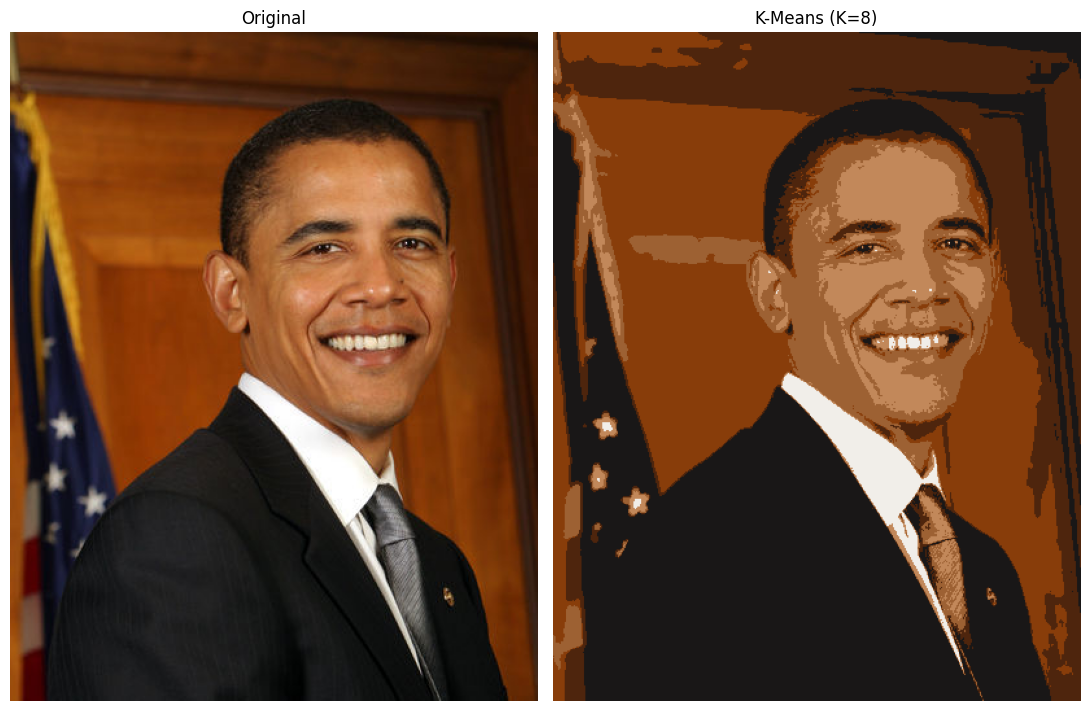

In [20]:
# Replace each pixel by its assigned centroid colour and show both images.
quantised = centroids[labels].reshape(ROWS, COLS, 3).astype(np.uint8)
original  = img.reshape(ROWS, COLS, 3).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(11, 7))
ax[0].imshow(original);  ax[0].set_title('Original');       ax[0].axis('off')
ax[1].imshow(quantised); ax[1].set_title('K-Means (K=8)');  ax[1].axis('off')
plt.tight_layout(); plt.show()
